# **Project 2 (S005)** — Phishing Email Detector using Machine Learning

### Team 39 — G04

**Members:**
- BENAISSA Bochra  
- SAKRI Anfel
- LARMED Kahina 
- NEGAB Rania 
- HADBI Sarra


## Introduction

Phishing emails are one of the most common forms of cyber attacks, designed to trick users into revealing sensitive information. This project builds a machine learning pipeline to automatically detect phishing emails by analyzing their content, structure, and metadata.

The dataset used is **CEAS_08**, it contains **39,154 emails** including sender information, recipient information, date, and labels for spam/legitimate classification.

---
## Data Preprocessing
**Student:** HADBI Sarra | **Group:** 4

This section covers loading, exploring, and cleaning the raw dataset.  
The output is `cleaned_CEAS_08.csv`.

## Step 1: Load the Dataset
Import required libraries

In [153]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

load the raw dataset for initial inspection.

In [155]:
df = pd.read_csv('CEAS_08.csv')
print(f"Dataset loaded successfully")

Dataset loaded successfully


### 1. First Look at the Data

In [157]:
df.head()

,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1


**Key observations:**
- The dataset contains 7 columns: `sender`, `receiver`, `date`, `subject`, `body`, `label`, and `urls`.  
- The `label` column is our target: **1 = phishing, 0 = legitimate**.  
- The `urls` column appears to be binary (0 or 1), indicating the presence of a URL in the email.

### 2. Dataset Shape

In [160]:
rows, cols = df.shape
print(f"Rows : {rows}")
print(f"Columns : {cols}")

Rows : 39154
Columns : 7


We have **39,154 emails** in total across 7 columns.

### 3. Dataset Info (Column Names & Data Types)

In [163]:
print("Dataset info:\n")
df.info()

Dataset info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39154 entries, 0 to 39153
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sender    39154 non-null  object
 1   receiver  38692 non-null  object
 2   date      39154 non-null  object
 3   subject   39126 non-null  object
 4   body      39154 non-null  object
 5   label     39154 non-null  int64 
 6   urls      39154 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 2.1+ MB


`date` is stored as a `object` string, it must be converted to `datetime`. We also have some missing values detected in `receiver` and `subject`. These problems will be handled later.

## Step 2: Data Description
Explore the dataset statistically and understand the distribution of classes.

### 1. Basic Statistics

In [167]:
df.describe(include='all')

,sender,receiver,date,subject,body,label,urls
count,39154,38692,39154,39126,39154,39154.000000,39154.00000
unique,24578,3693,38658,15436,39154,NaN,NaN
top,qydlqcws-iacfym@issues.apache.org,user6@gvc.ceas-challenge.cc,"Thu, 07 Aug 2008 21:38:18 -0100",CNN.com Daily Top 10,"Buck up, your troubles caused by small dimensi...",NaN,NaN
freq,462,1375,8,2930,1,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,0.557848,0.66997
std,NaN,NaN,NaN,NaN,NaN,0.496649,0.47023
min,NaN,NaN,NaN,NaN,NaN,0.000000,0.00000
25%,NaN,NaN,NaN,NaN,NaN,0.000000,0.00000
50%,NaN,NaN,NaN,NaN,NaN,1.000000,1.00000
75%,NaN,NaN,NaN,NaN,NaN,1.000000,1.00000


**Key observations:**
- `sender`: most senders appear only once (24578 unique values), typical of phishing campaigns using throwaway addresses (addresses created specifically for one-time use and then abandoned).
- `subject`: "CNN.com Daily Top 10" appears 2,930 times (seems like a recurring newsletter pattern).
- `body`: every email has a completely unique body.
- `label`: mean of **0.56** confirms the slight class imbalance.
- `urls`: mean of **0.67** means roughly 2 out of 3 emails contain a URL.

### 2. Class Distribution (label column)

Class Distribution:
                Count  Percentage (%)
Phishing (1)    21842           55.78
Legitimate (0)  17312           44.22


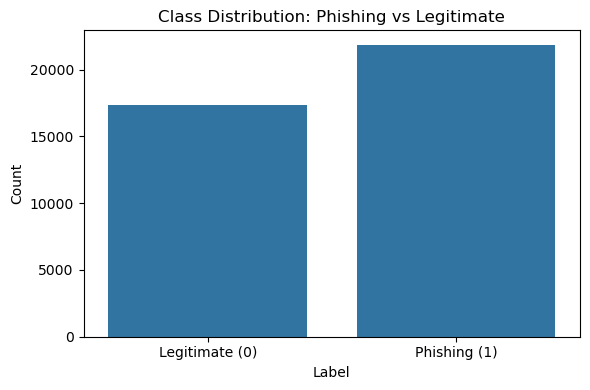

In [170]:
class_counts = df['label'].value_counts()
class_pct = df['label'].value_counts(normalize=True) * 100

class_summary = pd.DataFrame({
    'Count': class_counts,
    'Percentage (%)': class_pct.round(2)
})
class_summary.index = ['Phishing (1)', 'Legitimate (0)']

print("Class Distribution:")
print(class_summary)

# Plot
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df)
plt.xticks([0, 1], ['Legitimate (0)', 'Phishing (1)'])
plt.title('Class Distribution: Phishing vs Legitimate')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

We can clearly see that he dataset is slightly **imbalanced**.

### 3. URLs Column Overview

URL Distribution:
             Count  Percentage (%)
Has URL (1)  26232            67.0
No URL (0)   12922            33.0


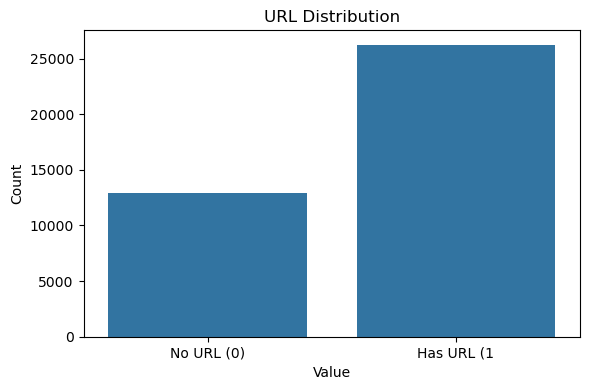

In [173]:
url_counts = df['urls'].value_counts()
url_pct = df['urls'].value_counts(normalize=True) * 100

url_summary = pd.DataFrame({
    'Count': url_counts,
    'Percentage (%)': url_pct.round(2)
})
url_summary.index = ['Has URL (1)', 'No URL (0)']

print("URL Distribution:")
print(url_summary)

# Plot
plt.figure(figsize=(6, 4))
sns.countplot(x='urls', data=df)
plt.xticks([0, 1], ['No URL (0)', 'Has URL (1'])
plt.title('URL Distribution')
plt.xlabel('Value')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 4. Check Missing Values

In [175]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

print(missing_df)

          Missing Count  Missing %
sender                0       0.00
receiver            462       1.18
date                  0       0.00
subject              28       0.07
body                  0       0.00
label                 0       0.00
urls                  0       0.00


Only `receiver` and `subject` have missing values and both are **minor**. `body` and `label` are complete with no missing values, which is critical since they are the main inputs for training. Therefore, we will handle our missing values by filling `receiver` with `'unknown'` and `subject` with `'no subject'`, preserving all rows since no data is too incomplete to keep.

### 5. Check Duplicates

In [178]:
dupes = df.duplicated().sum()
print(f"Duplicate rows found: {dupes}")

Duplicate rows found: 0


Thus, our dataset **does not contain** any duplicate rows.

## Step 3: Data Cleaning
Handle missing values, clean the text columns and convert data types when needed.

### 1. Handle Missing Values
- `receiver`: 462 missing (1.18%) → fill with `'unknown'`
- `subject`: 28 missing (0.07%) → fill with `'no subject'`

In [182]:
df['receiver'] = df['receiver'].fillna('unknown')
df['subject']  = df['subject'].fillna('no subject')

print("Missing values handled.")
print(f"Remaining nulls:\n{df.isnull().sum()}")

Missing values handled.
Remaining nulls:
sender      0
receiver    0
date        0
subject     0
body        0
label       0
urls        0
dtype: int64


### 2. Clean Text Columns (`subject` and `body`)
The raw `body` and `subject` columns are **preserved as-is** for feature engineering,
in order to extract HTML tags, URLs, and structural features directly from them.

For text vectorization, we will create separate cleaned versions: `subject_clean` and `body_clean`

Cleaning applied:
1. Lowercase all text
2. Remove extra whitespace / newlines / tabs
3. Remove non-ASCII characters
4. Remove special characters

In [184]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    # Lowercase
    text = text.lower()
    # Remove non-ASCII characters
    text = text.encode('ascii', errors='ignore').decode()
    # Remove special characters (keep letters, digits, spaces)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    # Remove extra whitespace / newlines / tabs
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['subject_clean'] = df['subject'].apply(clean_text)
df['body_clean']    = df['body'].apply(clean_text)

print("Clean text columns created (raw columns untouched).")
print("\nRaw body sample (first 200 chars):")
print(df['body'].iloc[2][:200])
print("\nCleaned body sample (first 200 chars):")
print(df['body_clean'].iloc[2][:200])

Clean text columns created (raw columns untouched).

Raw body sample (first 200 chars):
>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+= >THE DAILY TOP 10 >from CNN.com >Top videos and stories as of: Aug  1, 2008  3:58 PM EDT >+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=

Cleaned body sample (first 200 chars):
the daily top 10 from cnn com top videos and stories as of aug 1 2008 3 58 pm edt top 10 videos 1 montauk monster http www cnn com video partners email index html url video us 2008 07 31 moos montauk 


### 3. Convert `date` to Datetime
Converting the `date` column from string to `datetime` format.

In [186]:
df_raw = df.copy()
df['date'] = pd.to_datetime(df['date'], utc=True, errors='coerce')

print(f"Date column converted to datetime.")
print(f"Failed conversions (NaT): {df['date'].isna().sum()}")

nat_indexes = df[df['date'].isna()].index.tolist()

print("\nFailed dates before conversion (original values):")
print(df_raw.loc[nat_indexes, 'date'])

print("\nFailed dates after conversion:")
print(df.loc[nat_indexes, 'date'])

print(f"\nSample:\n{df['date'].head()}")

Date column converted to datetime.
Failed conversions (NaT): 15

Failed dates before conversion (original values):
6279            Tue, 05 Aug   Hora oficial do Brasil
7410                      Wed, 06 Aug   ????????????
8611                      Wed, 06 Aug   ?x?_????????
9600        Wed, 06 Aug   Westeurop?ische Normalzeit
12253           Wed, 06 Aug   K?z?p-eur?pai t?li id?
13848    Wed, 06 Aug   ora solare Europa occidentale
16105             Thu, 07 Aug   ???????? ???? (????)
17580               Wed, 06 Aug   Hora padr?o de GMT
18509          Thu, 07 Aug   Jerusalem Standard Time
19436                     Thu, 07 Aug   ????????????
20209            Tue, 05 Aug   SE Asia Standard Time
22195                     Thu, 07 Aug   ????????????
24797          Thu, 07 Aug   E. Europe Daylight Time
28161     Mon, 07 Aug   rodkowoeuropejski czas letni
38798              Fri, 08 Aug   India Standard Time
Name: date, dtype: object

Failed dates after conversion:
6279    NaT
7410    NaT
8611    

The 15 failed rows have truncated date values (e.g. `"Tue, 05 Aug"` with missing time and year), making them unrecoverable. They are kept as `NaT` since their other columns (`body`, `subject`, `sender`) are intact and valuable.

### 4. Final Dataset Overview

In [189]:
print("Final cleaned dataset info:\n")
df.info()
print(f"\nFinal shape : {df.shape}")
print(f"Columns     : {list(df.columns)}")

Final cleaned dataset info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39154 entries, 0 to 39153
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   sender         39154 non-null  object             
 1   receiver       39154 non-null  object             
 2   date           39139 non-null  datetime64[ns, UTC]
 3   subject        39154 non-null  object             
 4   body           39154 non-null  object             
 5   label          39154 non-null  int64              
 6   urls           39154 non-null  int64              
 7   subject_clean  39154 non-null  object             
 8   body_clean     39154 non-null  object             
dtypes: datetime64[ns, UTC](1), int64(2), object(6)
memory usage: 2.7+ MB

Final shape : (39154, 9)
Columns     : ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls', 'subject_clean', 'body_clean']


### 5. Preview Cleaned Data

In [191]:
df.head()

,sender,receiver,date,subject,body,label,urls,subject_clean,body_clean
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,2008-08-05 23:31:02+00:00,Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1,never agree to be a loser,buck up your troubles caused by small dimensio...
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,2008-08-05 23:31:03+00:00,Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1,befriend jenna jameson,upgrade your sex and pleasures with these tech...
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,2008-08-06 08:28:00+00:00,CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1,cnn com daily top 10,the daily top 10 from cnn com top videos and s...
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,2008-08-05 23:31:20+00:00,Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1,re svn commit r619753 in spamassassin trunk li...,would anyone object to removing so from this l...
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,2008-08-05 23:31:21+00:00,SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1,specialpricespharmmoreinfo,welcomefastshippingcustomersupport http 7iwfna...


## Step 4: Export Cleaned Dataset
Save the final cleaned dataset.

In [193]:
df.to_csv('cleaned_CEAS_08.csv', index=False)
print("Cleaned dataset exported as: cleaned_CEAS_08.csv")

Cleaned dataset exported as: cleaned_CEAS_08.csv


### Notes About the Cleaned Dataset — `cleaned_CEAS_08.csv`

The cleaned dataset contains **39,154 emails** across **9 columns**:

| Column | Type | Notes |
|---|---|---|
| `sender` | object | Raw, preserved for feature extraction |
| `receiver` | object | 462 missing values filled with `'unknown'` |
| `date` | datetime64 (UTC) | 15 missing values as `NaT` |
| `subject` | object | Raw, 28 missing values filled with `'no subject'` |
| `body` | object | Raw, fully intact (HTML and URLs preserved) |
| `label` | int64 | Target column: 1 = Phishing, 0 = Legitimate |
| `urls` | int64 | Binary: 1 = has URL, 0 = no URL |
| `subject_clean` | object | cleaned version of `subject` for text vectorization |
| `body_clean` | object | cleaned version of `body` for text vectorization |

**Role 2 (Feature Engineering):**
- You can drop any column you find useless.
- You can use raw `sender`, `receiver`, `body`, and `subject` for feature extraction
- `body` and `subject` retain HTML tags and URLs intentionally
- If the column `date` is used, you can  extract `hour`, `dayofweek`, and timezone directly from it. Handle the 15 `NaT` values when doing so.

**Role 3 (Text Vectorization):**
- Use `subject_clean` and `body_clean` for TF-IDF
- These columns are lowercased with special characters removed

**Role 4 (ML Engineer):**
- `label` is the target column (binary: 0 or 1)
- Dataset is slightly imbalanced (55.78% phishing, 44.22% legitimate) — consider F1-score over accuracy for evaluation
- `urls` is binary and ready to use as a feature directly

---
## Feature Engineering
**Student:** SAKRI Anfel | **Group:** 4

This section builds phishing indicators from the cleaned dataset produced by Role 1.  
Input: `cleaned_CEAS_08.csv` — Output: new feature columns saved to `featured_CEAS_08.csv`

**Features created:**
1. **URL features** — URL count, suspicious TLDs, IP-based URLs, URL length stats
2. **Keyword features** — phishing keyword hits in subject & body
3. **Structural features** — sender domain, sender/receiver mismatch, email hour/day, body length, punctuation ratios


### Setup — Import Libraries

In [197]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.parse import urlparse

print("Libraries imported successfully.")

Libraries imported successfully.


### Load the Cleaned Dataset

In [199]:
df = pd.read_csv('cleaned_CEAS_08.csv')

# The 'date' column needs to be re-parsed as datetime after loading from CSV
df['date'] = pd.to_datetime(df['date'], utc=True, errors='coerce')

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")

Dataset loaded: 39,154 rows × 9 columns
Columns: ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls', 'subject_clean', 'body_clean']


In [200]:
# Quick sanity check
df.head(3)

,sender,receiver,date,subject,body,label,urls,subject_clean,body_clean
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,2008-08-05 23:31:02+00:00,Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1,never agree to be a loser,buck up your troubles caused by small dimensio...
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,2008-08-05 23:31:03+00:00,Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1,befriend jenna jameson,upgrade your sex and pleasures with these tech...
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,2008-08-06 08:28:00+00:00,CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1,cnn com daily top 10,the daily top 10 from cnn com top videos and s...


---
## Feature Group 1 — URL Detection

Phishing emails heavily rely on deceptive URLs. We extract:
- **`url_count`** : total number of URLs found in the raw body
- **`has_ip_url`** : 1 if any URL uses a raw IP address instead of a domain name (a common phishing trick)
- **`has_suspicious_tld`** : 1 if any URL ends with a known high-risk TLD (.xyz, .top, .ru, etc.)
- **`max_url_length`** : length of the longest URL (phishing URLs are often obfuscated and very long)
- **`has_url_mismatch`** : 1 if URL domain differs from the sender's domain (link spoofing)

In [202]:
# --- Configuration ---
SUSPICIOUS_TLDS = {
    '.xyz', '.top', '.ru', '.cn', '.tk', '.ml', '.ga', '.cf',
    '.gq', '.pw', '.club', '.work', '.link', '.click', '.win',
    '.online', '.site', '.info', '.biz', '.pro'
}

URL_PATTERN = re.compile(
    r'https?://[^\s<>"{}|\\^`\[\]]+',
    re.IGNORECASE
)
IP_PATTERN = re.compile(
    r'https?://(\d{1,3}\.){3}\d{1,3}',
    re.IGNORECASE
)


def extract_urls(text):
    """Return list of all URLs found in a text string."""
    if pd.isna(text):
        return []
    return URL_PATTERN.findall(str(text))


def count_urls(text):
    """Total number of URLs in the text."""
    return len(extract_urls(text))


def has_ip_url(text):
    """1 if any URL uses a raw IP address (e.g. http://192.168.1.1/login)."""
    if pd.isna(text):
        return 0
    return int(bool(IP_PATTERN.search(str(text))))


def has_suspicious_tld(text):
    """1 if any URL ends with a known high-risk TLD."""
    urls = extract_urls(text)
    for url in urls:
        try:
            domain = urlparse(url).netloc.lower()
            # Remove port number if present
            domain = domain.split(':')[0]
            for tld in SUSPICIOUS_TLDS:
                if domain.endswith(tld):
                    return 1
        except Exception:
            continue
    return 0


def max_url_length(text):
    """Length of the longest URL found (0 if none)."""
    urls = extract_urls(text)
    if not urls:
        return 0
    return max(len(u) for u in urls)


def get_sender_domain(sender):
    """Extract domain from sender field, e.g. 'John <john@gmail.com>' → 'gmail.com'."""
    if pd.isna(sender):
        return ''
    match = re.search(r'@([\w.\-]+)', str(sender))
    return match.group(1).lower() if match else ''


def has_url_mismatch(row):
    """1 if a URL in body belongs to a domain different from the sender's domain."""
    sender_domain = get_sender_domain(row['sender'])
    if not sender_domain:
        return 0
    urls = extract_urls(row['body'])
    for url in urls:
        try:
            url_domain = urlparse(url).netloc.lower().split(':')[0]
            # Strip www.
            url_domain = re.sub(r'^www\.', '', url_domain)
            sender_domain_stripped = re.sub(r'^www\.', '', sender_domain)
            if url_domain and url_domain != sender_domain_stripped:
                return 1
        except Exception:
            continue
    return 0


print("URL extraction functions defined.")

URL extraction functions defined.


In [203]:
print("Extracting URL features...")

df['url_count']          = df['body'].apply(count_urls)
df['has_ip_url']         = df['body'].apply(has_ip_url)
df['has_suspicious_tld'] = df['body'].apply(has_suspicious_tld)
df['max_url_length']     = df['body'].apply(max_url_length)
df['has_url_mismatch']   = df.apply(has_url_mismatch, axis=1)

print("URL features extracted.")
print(df[['url_count','has_ip_url','has_suspicious_tld','max_url_length','has_url_mismatch']].describe())

Extracting URL features...
URL features extracted.
          url_count    has_ip_url  has_suspicious_tld  max_url_length  \
count  39154.000000  39154.000000        39154.000000    39154.000000   
mean       3.344716      0.000690            0.010676       36.401619   
std        8.937602      0.026251            0.102772       39.425206   
min        0.000000      0.000000            0.000000        0.000000   
25%        0.000000      0.000000            0.000000        0.000000   
50%        1.000000      0.000000            0.000000       24.000000   
75%        2.000000      0.000000            0.000000       58.000000   
max      467.000000      1.000000            1.000000      307.000000   

       has_url_mismatch  
count      39154.000000  
mean           0.612479  
std            0.487190  
min            0.000000  
25%            0.000000  
50%            1.000000  
75%            1.000000  
max            1.000000  


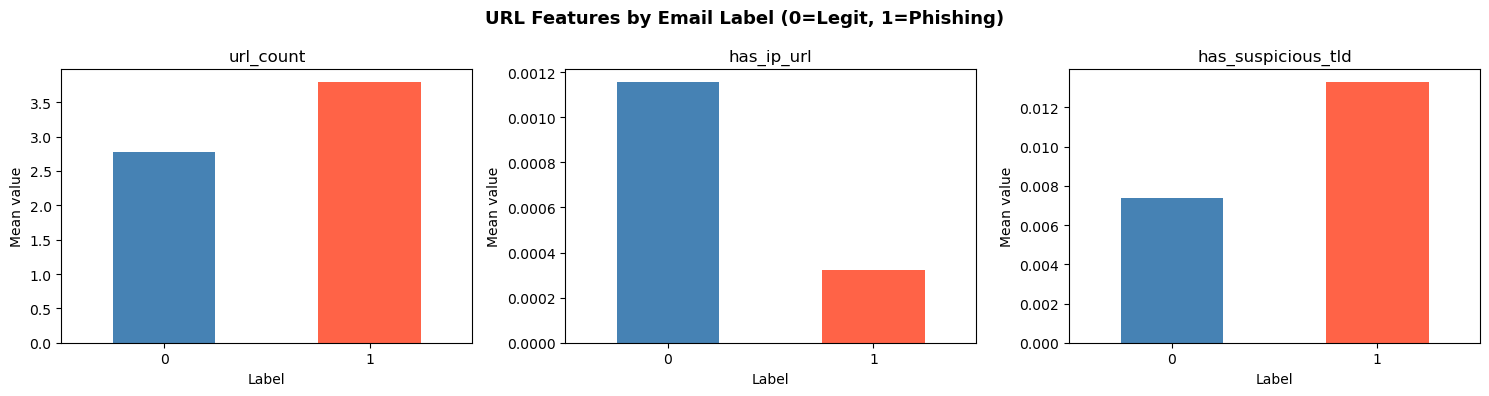

In [204]:
# Visualize URL feature distributions by label
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('URL Features by Email Label (0=Legit, 1=Phishing)', fontsize=13, fontweight='bold')

for ax, col in zip(axes, ['url_count', 'has_ip_url', 'has_suspicious_tld']):
    df.groupby('label')[col].mean().plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], rot=0)
    ax.set_title(col)
    ax.set_ylabel('Mean value')
    ax.set_xlabel('Label')

plt.tight_layout()
plt.show()

---
## Feature Group 2 — Keyword Extraction

Phishing emails use a recognizable vocabulary designed to create urgency, fear, or greed. We count how many phishing keywords appear in the subject and body:
- **`subject_keyword_hits`** : number of phishing keywords found in the subject
- **`body_keyword_hits`** : number of phishing keywords found in the body
- **`total_keyword_hits`** : combined score
- **`has_urgency_words`** : 1 if the email contains urgent-action language

In [206]:
# Comprehensive phishing keyword list
PHISHING_KEYWORDS = [
    # Account / Credential theft
    'verify', 'verification', 'confirm', 'validate', 'authenticate',
    'account', 'password', 'username', 'login', 'sign in', 'credential',
    'update your', 're-enter', 'reactivate', 'suspended', 'locked',
    # Financial lures
    'bank', 'paypal', 'payment', 'invoice', 'transaction', 'transfer',
    'wire', 'refund', 'prize', 'winner', 'lottery', 'reward', 'cashback',
    'bitcoin', 'crypto', 'investment', 'profit', 'million', 'inheritance',
    # Urgency / Fear
    'urgent', 'immediately', 'action required', 'limited time', 'expire',
    'deadline', 'last chance', 'warning', 'alert', 'important notice',
    'your account will be', 'failure to', 'risk', 'suspended',
    # Generic phishing
    'click here', 'click below', 'follow this link', 'dear customer',
    'dear user', 'free', 'offer', 'unsubscribe', 'opt out',
    'congratulations', 'selected', 'chosen', 'claim', 'gift'
]

URGENCY_KEYWORDS = [
    'urgent', 'immediately', 'action required', 'expire', 'expires',
    'deadline', 'last chance', 'limited time', 'act now', 'respond now',
    'failure to act', 'your account will be'
]


def count_keywords(text, keyword_list):
    """Count how many keywords from the list appear in text."""
    if pd.isna(text):
        return 0
    text_lower = str(text).lower()
    return sum(1 for kw in keyword_list if kw in text_lower)


def has_urgency(text):
    """1 if the text contains urgency/fear language."""
    return int(count_keywords(text, URGENCY_KEYWORDS) > 0)


print(f"Phishing keyword list: {len(PHISHING_KEYWORDS)} keywords")
print(f"Urgency keyword list : {len(URGENCY_KEYWORDS)} keywords")

Phishing keyword list: 63 keywords
Urgency keyword list : 12 keywords


In [207]:
print("Extracting keyword features...")

df['subject_keyword_hits'] = df['subject_clean'].apply(
    lambda x: count_keywords(x, PHISHING_KEYWORDS)
)
df['body_keyword_hits'] = df['body_clean'].apply(
    lambda x: count_keywords(x, PHISHING_KEYWORDS)
)
df['total_keyword_hits'] = df['subject_keyword_hits'] + df['body_keyword_hits']

# Use subject_clean + body_clean combined for urgency check
df['has_urgency_words'] = (df['subject_clean'].fillna('') + ' ' + df['body_clean'].fillna('')).apply(has_urgency)

print("Keyword features extracted.")
print(df[['subject_keyword_hits','body_keyword_hits','total_keyword_hits','has_urgency_words']].describe())

Extracting keyword features...
Keyword features extracted.
       subject_keyword_hits  body_keyword_hits  total_keyword_hits  \
count          39154.000000       39154.000000        39154.000000   
mean               0.086198           0.953466            1.039664   
std                0.294514           1.452956            1.570758   
min                0.000000           0.000000            0.000000   
25%                0.000000           0.000000            0.000000   
50%                0.000000           0.000000            1.000000   
75%                0.000000           1.000000            1.000000   
max                3.000000          19.000000           20.000000   

       has_urgency_words  
count       39154.000000  
mean            0.044542  
std             0.206299  
min             0.000000  
25%             0.000000  
50%             0.000000  
75%             0.000000  
max             1.000000  


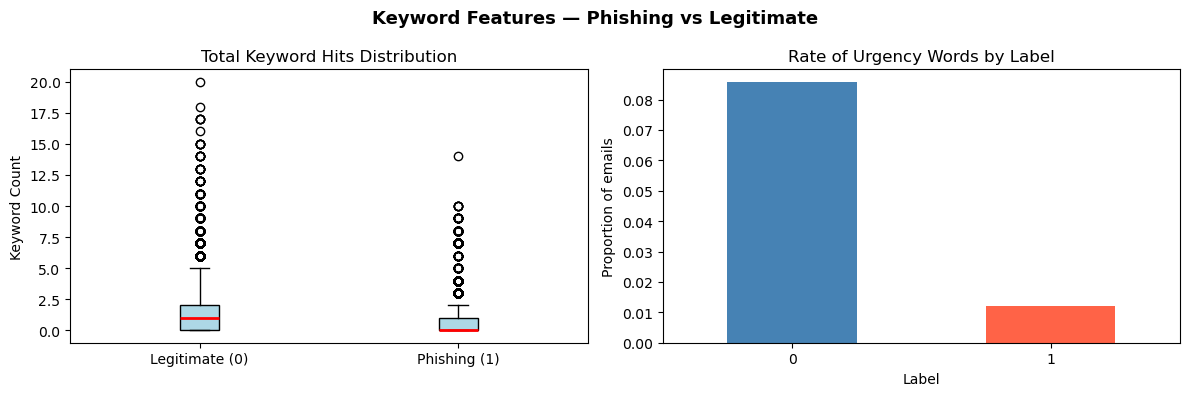

In [208]:
# Compare keyword hits between phishing and legitimate emails
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Keyword Features — Phishing vs Legitimate', fontsize=13, fontweight='bold')

# Box plot: total keyword hits
phishing = df[df['label'] == 1]['total_keyword_hits']
legit    = df[df['label'] == 0]['total_keyword_hits']
axes[0].boxplot([legit, phishing], tick_labels=['Legitimate (0)', 'Phishing (1)'],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Total Keyword Hits Distribution')
axes[0].set_ylabel('Keyword Count')

# Bar chart: urgency word rate
df.groupby('label')['has_urgency_words'].mean().plot(
    kind='bar', ax=axes[1], color=['steelblue', 'tomato'], rot=0
)
axes[1].set_title('Rate of Urgency Words by Label')
axes[1].set_ylabel('Proportion of emails')
axes[1].set_xlabel('Label')

plt.tight_layout()
plt.show()

---
## Feature Group 3 — Structural Features

Beyond content, the *structure* of an email reveals phishing patterns:
- **`sender_domain`** : the domain part of the sender address
- **`sender_is_free_email`** : 1 if sender uses a free webmail provider (gmail, yahoo, hotmail…)
- **`sender_receiver_domain_match`** : 1 if sender and receiver share the same domain
- **`body_length`** : character length of raw body
- **`subject_length`** : character length of subject
- **`body_exclamation_count`** : number of '!' in body (agressive/urgent tone)
- **`body_question_count`** : number of '?' in body
- **`has_html_tags`** : 1 if body contains HTML (emails with rich HTML are more often phishing)
- **`sending_hour`** : hour of the day the email was sent (NaT → -1)
- **`sending_dayofweek`** : day of week (0=Monday … 6=Sunday, NaT → -1)

In [210]:
FREE_EMAIL_DOMAINS = {
    'gmail.com', 'yahoo.com', 'hotmail.com', 'outlook.com',
    'live.com', 'aol.com', 'icloud.com', 'protonmail.com',
    'mail.com', 'zoho.com', 'yandex.com', 'gmx.com'
}

HTML_TAG_PATTERN = re.compile(r'<[a-zA-Z][^>]*>', re.IGNORECASE)


def extract_domain(email_field):
    """Extract domain from 'Name <email@domain.com>' or plain 'email@domain.com'."""
    if pd.isna(email_field):
        return 'unknown'
    match = re.search(r'@([\w.\-]+)', str(email_field))
    return match.group(1).lower() if match else 'unknown'


def is_free_email(sender):
    """1 if sender uses a free webmail provider."""
    domain = extract_domain(sender)
    return int(domain in FREE_EMAIL_DOMAINS)


def domain_match(row):
    """1 if sender domain == receiver domain (internal email)."""
    sender_domain   = extract_domain(row['sender'])
    receiver_domain = extract_domain(row['receiver'])
    if sender_domain == 'unknown' or receiver_domain == 'unknown':
        return 0
    return int(sender_domain == receiver_domain)


def has_html(text):
    """1 if body contains HTML tags."""
    if pd.isna(text):
        return 0
    return int(bool(HTML_TAG_PATTERN.search(str(text))))


print("Structural feature functions defined.")

Structural feature functions defined.


In [211]:
print("Extracting structural features...")

# Sender / Receiver domain features
df['sender_domain']                 = df['sender'].apply(extract_domain)
df['sender_is_free_email']          = df['sender'].apply(is_free_email)
df['sender_receiver_domain_match']  = df.apply(domain_match, axis=1)

# Body / Subject length
df['body_length']    = df['body'].fillna('').apply(len)
df['subject_length'] = df['subject'].fillna('').apply(len)

# Punctuation counts in raw body
df['body_exclamation_count'] = df['body'].fillna('').apply(lambda x: str(x).count('!'))
df['body_question_count']    = df['body'].fillna('').apply(lambda x: str(x).count('?'))

# HTML presence
df['has_html_tags'] = df['body'].apply(has_html)

# Time-based features (handle the 15 NaT values with -1)
df['sending_hour']      = df['date'].apply(lambda d: d.hour      if pd.notna(d) else -1)
df['sending_dayofweek'] = df['date'].apply(lambda d: d.dayofweek if pd.notna(d) else -1)

print("Structural features extracted.")

structural_cols = [
    'sender_is_free_email', 'sender_receiver_domain_match',
    'body_length', 'subject_length',
    'body_exclamation_count', 'body_question_count',
    'has_html_tags', 'sending_hour', 'sending_dayofweek'
]
print(df[structural_cols].describe().round(2))

Extracting structural features...
Structural features extracted.
       sender_is_free_email  sender_receiver_domain_match  body_length  \
count              39154.00                      39154.00     39154.00   
mean                   0.08                          0.03      1571.08   
std                    0.27                          0.18      3615.81   
min                    0.00                          0.00        14.00   
25%                    0.00                          0.00       224.00   
50%                    0.00                          0.00       570.00   
75%                    0.00                          0.00      1643.00   
max                    1.00                          1.00    143996.00   

       subject_length  body_exclamation_count  body_question_count  \
count        39154.00                39154.00             39154.00   
mean            38.90                    0.93                 2.15   
std             20.76                    7.49             

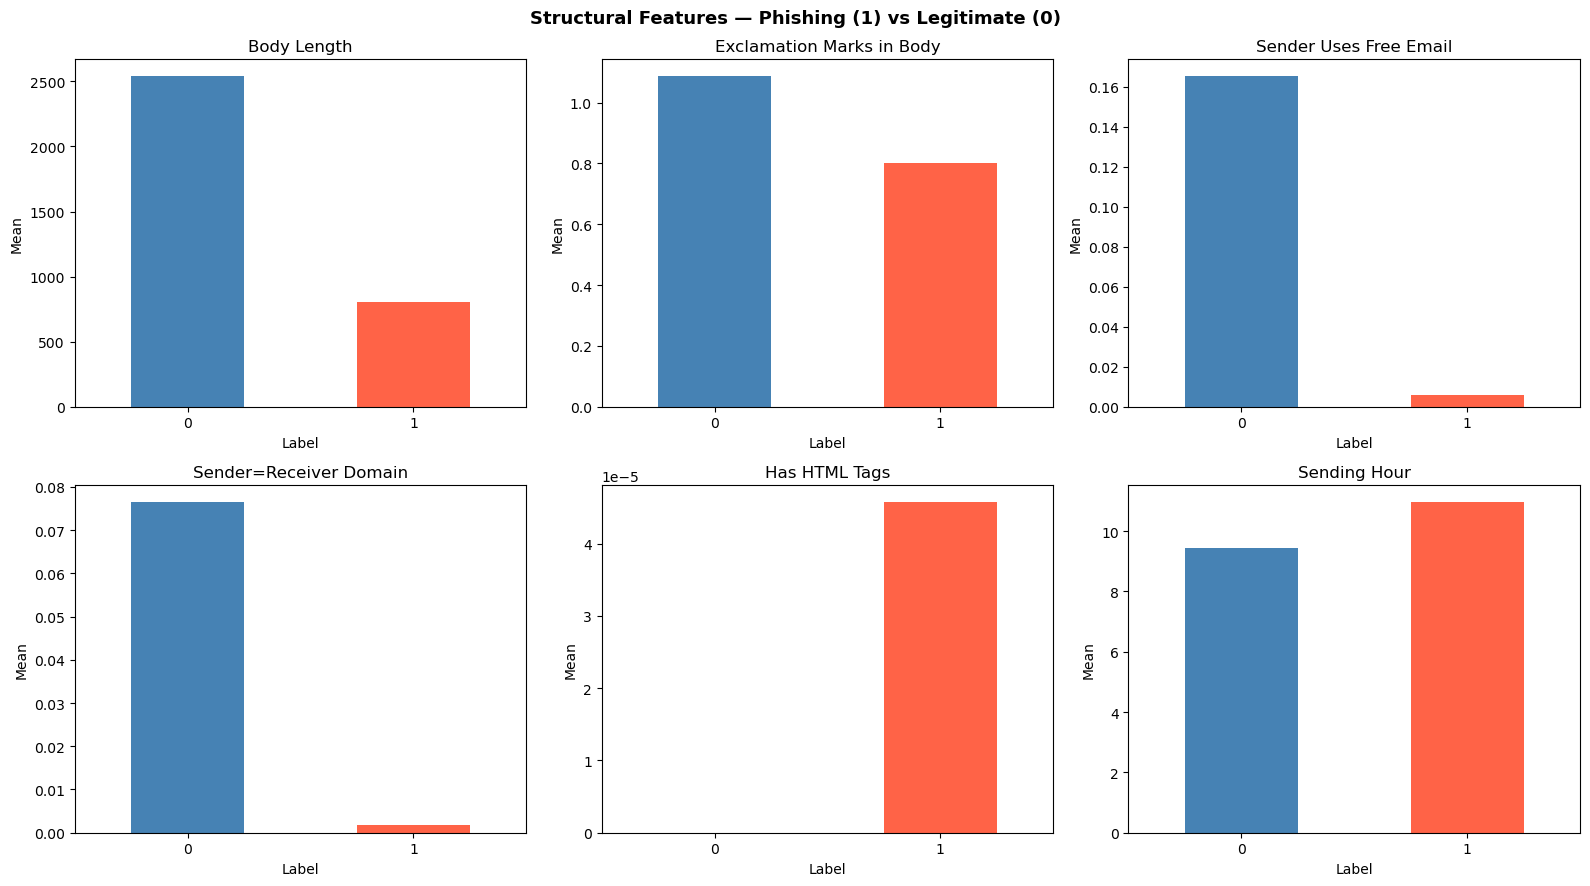

In [212]:
# Visualize structural features
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Structural Features — Phishing (1) vs Legitimate (0)', fontsize=13, fontweight='bold')

plot_cols = [
    ('body_length',                'Body Length'),
    ('body_exclamation_count',     'Exclamation Marks in Body'),
    ('sender_is_free_email',       'Sender Uses Free Email'),
    ('sender_receiver_domain_match','Sender=Receiver Domain'),
    ('has_html_tags',              'Has HTML Tags'),
    ('sending_hour',               'Sending Hour'),
]

for ax, (col, title) in zip(axes.flatten(), plot_cols):
    df.groupby('label')[col].mean().plot(kind='bar', ax=ax,
                                         color=['steelblue', 'tomato'], rot=0)
    ax.set_title(title)
    ax.set_ylabel('Mean')
    ax.set_xlabel('Label')

plt.tight_layout()
plt.show()

---
## Summary of All New Features

In [214]:
NEW_FEATURES = [
    # URL features
    'url_count', 'has_ip_url', 'has_suspicious_tld',
    'max_url_length', 'has_url_mismatch',
    # Keyword features
    'subject_keyword_hits', 'body_keyword_hits',
    'total_keyword_hits', 'has_urgency_words',
    # Structural features
    'sender_domain', 'sender_is_free_email', 'sender_receiver_domain_match',
    'body_length', 'subject_length',
    'body_exclamation_count', 'body_question_count',
    'has_html_tags', 'sending_hour', 'sending_dayofweek'
]

print(f"Total new features created: {len(NEW_FEATURES)}")
print("\nFeature types:")
print(df[NEW_FEATURES].dtypes)
print("\nMissing values in new features:")
print(df[NEW_FEATURES].isnull().sum())

Total new features created: 19

Feature types:
url_count                        int64
has_ip_url                       int64
has_suspicious_tld               int64
max_url_length                   int64
has_url_mismatch                 int64
subject_keyword_hits             int64
body_keyword_hits                int64
total_keyword_hits               int64
has_urgency_words                int64
sender_domain                   object
sender_is_free_email             int64
sender_receiver_domain_match     int64
body_length                      int64
subject_length                   int64
body_exclamation_count           int64
body_question_count              int64
has_html_tags                    int64
sending_hour                     int64
sending_dayofweek                int64
dtype: object

Missing values in new features:
url_count                       0
has_ip_url                      0
has_suspicious_tld              0
max_url_length                  0
has_url_mismatch             

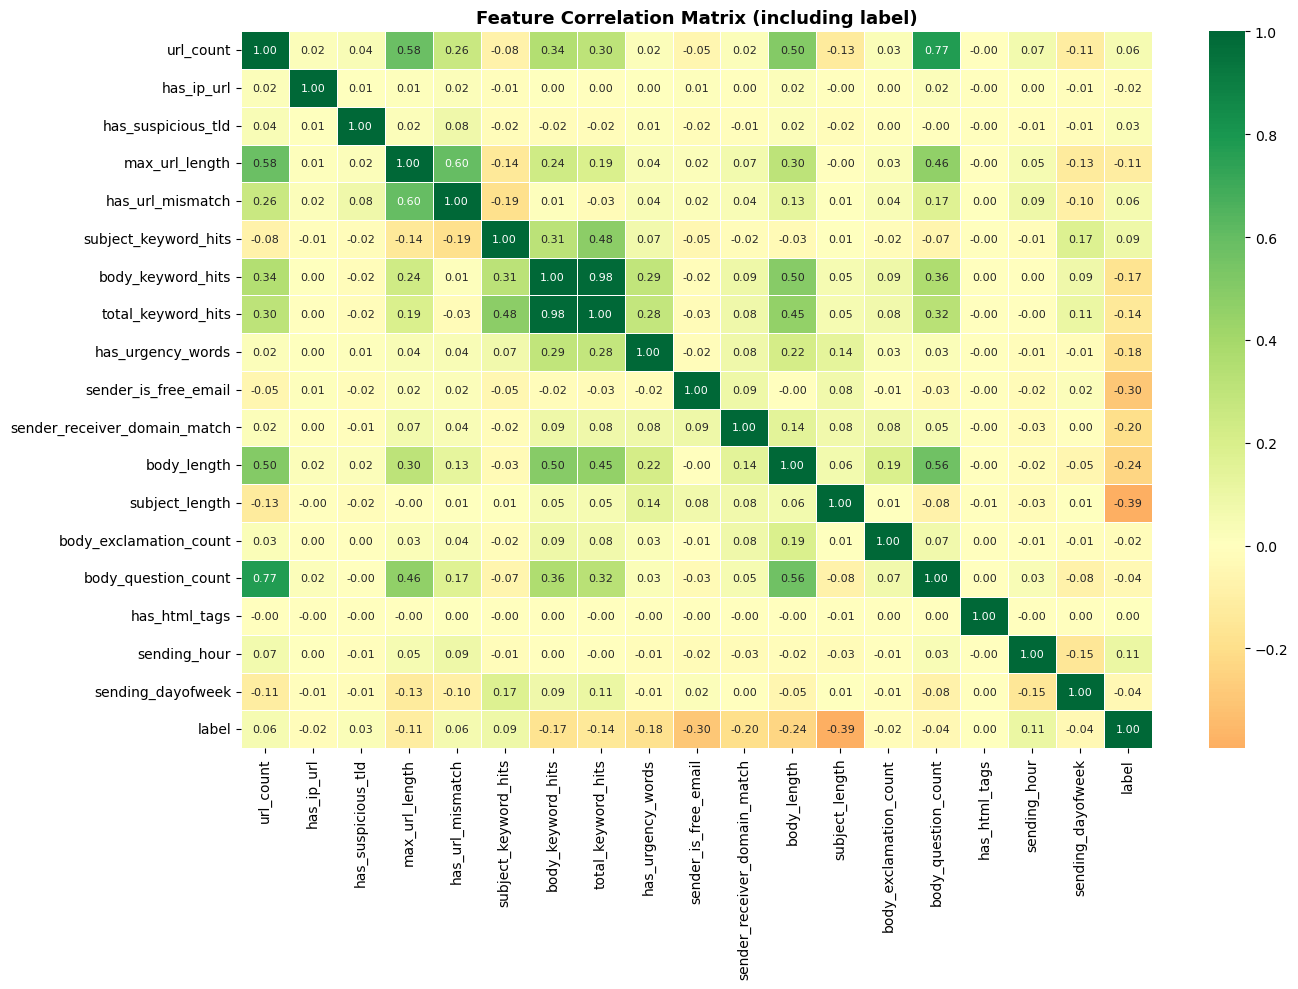

In [215]:
# Correlation heatmap of numeric features with label
numeric_features = [f for f in NEW_FEATURES if f != 'sender_domain']

corr = df[numeric_features + ['label']].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Feature Correlation Matrix (including label)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [216]:
# Print correlation with label — sorted by absolute value
label_corr = corr['label'].drop('label').abs().sort_values(ascending=False)
print("Features sorted by correlation strength with label:")
print(label_corr.to_string())

Features sorted by correlation strength with label:
subject_length                  0.394121
sender_is_free_email            0.297797
body_length                     0.239108
sender_receiver_domain_match    0.202852
has_urgency_words               0.177460
body_keyword_hits               0.172852
total_keyword_hits              0.143117
sending_hour                    0.111497
max_url_length                  0.108472
subject_keyword_hits            0.089448
has_url_mismatch                0.057976
url_count                       0.055961
sending_dayofweek               0.041028
body_question_count             0.040173
has_suspicious_tld              0.028432
body_exclamation_count          0.018946
has_ip_url                      0.015793
has_html_tags                   0.004499


## Export Featured Dataset

Save the enriched dataset for Role 3 (Text Vectorization) and Role 4 (ML Engineer).

In [218]:
df.to_csv('featured_CEAS_08.csv', index=False)
print(f"Featured dataset saved: featured_CEAS_08.csv")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nAll columns: {list(df.columns)}")

Featured dataset saved: featured_CEAS_08.csv
Shape: 39,154 rows × 28 columns

All columns: ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls', 'subject_clean', 'body_clean', 'url_count', 'has_ip_url', 'has_suspicious_tld', 'max_url_length', 'has_url_mismatch', 'subject_keyword_hits', 'body_keyword_hits', 'total_keyword_hits', 'has_urgency_words', 'sender_domain', 'sender_is_free_email', 'sender_receiver_domain_match', 'body_length', 'subject_length', 'body_exclamation_count', 'body_question_count', 'has_html_tags', 'sending_hour', 'sending_dayofweek']


### Notes for Role 3 (Text Vectorization) and Role 4 (ML Engineer)

The output file `featured_CEAS_08.csv` adds **19 new columns** to the cleaned dataset.

| Group | Features | Notes |
|---|---|---|
| **URL** | `url_count`, `has_ip_url`, `has_suspicious_tld`, `max_url_length`, `has_url_mismatch` | All numeric |
| **Keyword** | `subject_keyword_hits`, `body_keyword_hits`, `total_keyword_hits`, `has_urgency_words` | All numeric |
| **Structural** | `sender_is_free_email`, `sender_receiver_domain_match`, `body_length`, `subject_length`, `body_exclamation_count`, `body_question_count`, `has_html_tags`, `sending_hour`, `sending_dayofweek` | All numeric (hour/day = -1 for missing dates) |
| **String** | `sender_domain` | One-hot encode or frequency-encode if needed |

**Top features by correlation with label:**
- `subject_length` (0.39), `sender_is_free_email` (0.30), `body_length` (0.24), `sender_receiver_domain_match` (0.20)
- Note: negative correlation means the feature is higher in legitimate emails — this is expected, ML models handle direction automatically.

**`has_html_tags` warning:** nearly 0 for all rows because Sarra's cleaning already stripped HTML from `body_clean`. Low discriminative power — safe to drop if needed.

**`total_keyword_hits`** is highly correlated with `body_keyword_hits` (r=0.98) — Role 4 may consider dropping one to reduce redundancy.

**For Role 3:** Use `subject_clean` and `body_clean` for TF-IDF, then combine with the numeric features above using `scipy.sparse.hstack`.

**For Role 4:** Use all numeric features directly. The `label` column (0/1) is the target. Dataset is slightly imbalanced (55.8% phishing) — prefer F1-score over accuracy.

---

### Important for All Remaining Roles

**Starting point:** Load `featured_CEAS_08.csv` — NOT `cleaned_CEAS_08.csv`

`featured_CEAS_08.csv` contains everything from the cleaned dataset + 19 new feature columns ready to use.
```python
# How to load it
df = pd.read_csv('featured_CEAS_08.csv')
```

---

### Feature Analysis Findings (CEAS_08 Dataset)

**Most discriminative features** (by correlation with label):

| Rank | Feature | Correlation | Meaning |
|---|---|---|---|
| 1 | `subject_length` | 0.39 | Phishing emails have **shorter** subjects |
| 2 | `sender_is_free_email` | 0.30 | Legit emails use free email more |
| 3 | `body_length` | 0.24 | Phishing emails have **shorter** bodies |
| 4 | `sender_receiver_domain_match` | 0.20 | Phishing never comes from same domain |
| 5 | `body_keyword_hits` | 0.17 | Keyword detection contributes moderately |

**Least useful features in this dataset:**
- `has_html_tags` (0.004) — HTML was stripped by preprocessing, nearly zero signal
- `has_ip_url` (0.016) — IP-based URLs are extremely rare (0.07% of emails)
- `body_exclamation_count` (0.019) — minimal difference between classes

**Key insight about this dataset:**
> Phishing emails in CEAS_08 are characterized by being **short, using custom 
> fake domains, and arriving from external senders** — NOT by aggressive language 
> or suspicious URLs as commonly expected.  
> Structural features outperformed URL and keyword features entirely.

**Feature group ranking by overall contribution:**
```
1st - Structural features  → subject_length, body_length, sender domain
2nd - Keyword features     → body_keyword_hits, has_urgency_words
3rd - URL features         → max_url_length is the only useful URL feature
```